# Env Setup

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import pylab as py

# Load Data

In [2]:
df = pd.read_csv('Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


# Clean up

In [4]:
# clean-up code here if any
df = pd.get_dummies(df, dtype = int, drop_first = True)
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91.0,1
1,4,82,4,2,65.0,0
2,8,51,7,2,45.0,1
3,5,52,5,2,36.0,1
4,7,75,8,5,66.0,0


# Exploration

In [5]:
# Exploration code here

# Method 1: MLR

### check for multicoliniarity:

In [6]:
cor = df.drop('Performance Index', axis=1).corr()
print(cor)

                                  Hours Studied  Previous Scores  Sleep Hours  \
Hours Studied                          1.000000        -0.012390     0.001245   
Previous Scores                       -0.012390         1.000000     0.005944   
Sleep Hours                            0.001245         0.005944     1.000000   
Sample Question Papers Practiced       0.017463         0.007888     0.003990   
Extracurricular Activities_Yes         0.003873         0.008369    -0.023284   

                                  Sample Question Papers Practiced  \
Hours Studied                                             0.017463   
Previous Scores                                           0.007888   
Sleep Hours                                               0.003990   
Sample Question Papers Practiced                          1.000000   
Extracurricular Activities_Yes                            0.013103   

                                  Extracurricular Activities_Yes  
Hours Studied            

In [7]:
pd.Series(np.linalg.inv(cor.values).diagonal(), index = cor.index)

Hours Studied                       1.000478
Previous Scores                     1.000326
Sleep Hours                         1.000600
Sample Question Papers Practiced    1.000557
Extracurricular Activities_Yes      1.000802
dtype: float64

There are no predictor variables with VIF values greater than 5 so no verriable is concerned to have high correlation.

### Build MLR model:

In [8]:
model = smf.ols(
    formula='Q("Performance Index") ~ Q("Hours Studied") + Q("Previous Scores") + Q("Sleep Hours") + Q("Extracurricular Activities_Yes") + Q("Sample Question Papers Practiced")',
    data=df
)
result = model.fit()

In [9]:
predictions = result.predict()
residuals = result.resid
exog = result.model.exog

print (len(df))
print (len(predictions))
print(len(residuals))
print(len(exog))

10000
10000
10000
10000


### Check for heteroscedasticity:

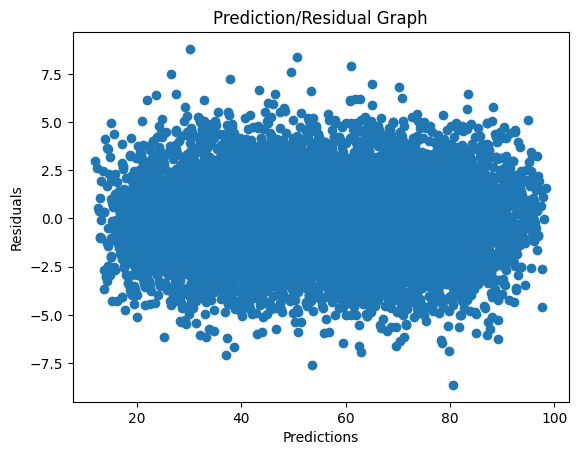

In [10]:
plt.scatter(predictions, residuals)
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.title('Prediction/Residual Graph')
plt.show()

In [11]:
lagrange, l_p_value, f_value, f_p_value = het_breuschpagan(residuals, exog)
print (l_p_value)
print (f_p_value)

0.8266745765790919
0.8267804553854452


We fail to reject the null hypothesis of homoscedasticity therefore we infer that heteroscedasticity does not exist.

The visual and statistical results show that the assumption is met.

### Check for normality of residuals

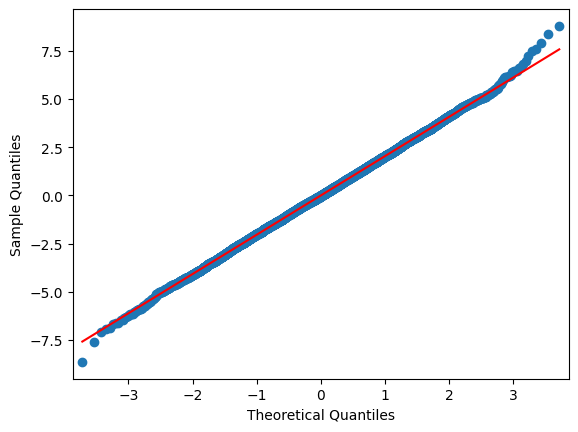

Statistic=1.000, p=0.386
Sample looks Gaussian (fail to reject H0)


C:\Users\Nati\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


In [12]:
sm.qqplot(residuals, line='s')
plt.show()
stat, p = shapiro(residuals)
print('Statistic=%.3f, p=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

The visual test suggests the residual are normally distributed, and furthermore the shapiro-wilk test shwes that we fail to reject the null hypothesis of normality. However it is important to mention that shapiro-wilk test does not perofrm well for data sets with size greater than 5000 (our dataset size is 10,000) but given the visual test it is safe to say the assumption is met.

In [13]:
dw_test = durbin_watson(residuals)
print(dw_test)

2.0009001250688563


**** Need to add notes on durbin_watson test (correlation between residuals) *****

In [14]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Q("Performance Index")   R-squared:                       0.989
Model:                                OLS   Adj. R-squared:                  0.989
Method:                     Least Squares   F-statistic:                 1.757e+05
Date:                    Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                            18:12:52   Log-Likelihood:                -21307.
No. Observations:                   10000   AIC:                         4.263e+04
Df Residuals:                        9994   BIC:                         4.267e+04
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                               -34.0756      0.127   -268.010      0.000     -34.325     -33.826
Q("Hours Studied")                        2.8530      0.008    362.353      0.000       2.838       2.868
Q("Previous Scores")                      1.0184      0.001    866.450      0.000       1.016       1.021
Q("Sleep Hours")                          0.4806      0.012     39.972      0.000       0.457       0.504
Q("Extracurricular Activities_Yes")       0.6129      0.041     15.029      0.000       0.533       0.693
Q("Sample Question Papers Practiced")     0.1938      0.007     27.257      0.000       0.180       0.208
==============================================================================
Omnibus:                        3.851   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.146   Jarque-Bera (JB):                4.036
Skew:                           0.013   Prob(JB):                        0.133
Kurtosis:                       3.095   Cond. No.                         452.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

$\hat{Y} = - 34.08 + 2.85X_{HS} + 1.02X_{PS} + 0.48X_{SH} + 0.61X_{EAYes} + 0.19X_{SQPP}$

# Method 2:

# Method 3: